# CosMx Spatial Transcriptomics Tutorial (Google Colab Version)

Welcome to the CosMx spatial omics tutorial using Python, Scanpy, and Squidpy. This notebook introduces spatial transcriptomics using NanoString's CosMx SMI data. We will load a public dataset, perform basic preprocessing, and run spatial analyses.

**Dataset**: Lung5_Rep1 public demo dataset from NanoString.

---

## Step 1: Install required packages
Install core spatial omics analysis tools: `scanpy`, `squidpy`, `anndata`, and visualization libraries.

In [1]:
!pip install -U squidpy scanpy anndata matplotlib seaborn gdown python-igraph leidenalg --quiet
!pip install "numcodecs<0.11.0" --quiet

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.3/161.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

## Step 2: Download Data (CosMx public dataset)
This includes expression matrix, metadata, and cell coordinates for CosMx SMI data (one example of imaging-based spatial transcriptomics) on human lung tissue.


In [2]:
import os
import tarfile

# Your shared file ID from google drive
file_id = "1ClBjGL3XANRmJteX1-bMRb3lPAmexFFG"
archive_path = "SMSS_data.tar.gz"
extract_dir = "smss_data"
os.makedirs(extract_dir, exist_ok=True)

# Download the archive
if not os.path.exists(archive_path):
    print("Downloading from Google Drive...")
    !gdown --id {file_id} -O {archive_path}
else:
    print("File already downloaded.")

# Extract the archive
print("Extracting archive...")
with tarfile.open(archive_path, "r:gz") as tar:
    tar.extractall(path=extract_dir)

print("Extraction complete. Files inside:", os.listdir(extract_dir))

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1ClBjGL3XANRmJteX1-bMRb3lPAmexFFG
From (redirected): https://drive.google.com/uc?id=1ClBjGL3XANRmJteX1-bMRb3lPAmexFFG&confirm=t&uuid=5092b56b-b9ef-4d0d-b37f-7eb04cd226c6
To: /content/SMSS_data.tar.gz
100% 1.57G/1.57G [00:22<00:00, 69.0MB/s]
Extracting archive...
Extraction complete. Files inside: ['Lung5_Rep1']


## Step 3: Load dataset into AnnData using Squidpy
We use Squidpy's `read.nanostring()` function to parse the CosMx flat files.

**CosMx Data format:**
This dataset is structured as flat files from a CosMx SMI run. These files contain subcellular-resolution transcriptomics data from multiple fields of view (FOVs). Here's what each file does:

### `exprMat.csv` — Gene Expression Matrix
- **Rows**: single cells (indexed by `cell_ID`)
- **Columns**: gene targets (from a ~1000-plex panel in this example, we will get to experience whole-transcriptome data later in the course)
- **Values**: transcript counts (UMI) per gene per cell
- Used to construct `.X` in the `AnnData` object

### `metadata.csv` — Cell-Level Annotations
- Each row represents one segmented cell
- Contains:
  - `cell_ID`: unique cell identifier
  - `X`, `Y`: cell spatial coordinates (in pixels)
  - `FOV`: the field of view this cell came from
  - `Area`, `Nucleus_Area`, `Cytoplasm_Area`, etc.
  - Optional annotations: cell type, quality flags, segmentation labels
- Used to populate `.obs` and `.obsm['spatial']`

### `fov_positions.csv` — Global Layout of FOVs
- Maps FOV IDs (e.g., 1, 2, 3...) to their positions in the whole tissue
- Allows for reassembly of larger tissue regions from multiple FOVs
- Stored in `.uns['spatial']` as part of FOV metadata

These three files together allow you to:
- Build a full `AnnData` object
- Perform spatial plotting (`spatial_scatter`, `spatial_segment`)
- Run neighborhood or spatial statistics

In [3]:
import squidpy as sq

adata = sq.read.nanostring(
    path="smss_data/Lung5_Rep1/Lung5_Rep1-Flat_files_and_images/",
    counts_file="Lung5_Rep1_exprMat_file.csv",
    meta_file="Lung5_Rep1_metadata_file.csv",
    fov_file="Lung5_Rep1_fov_positions_file.csv"
)

adata

/usr/lib/python3.11/importlib/__init__.py:126: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  return _bootstrap._gcd_import(name[level:], package, level)
/usr/local/lib/python3.11/dist-packages/cudf/utils/_ptxcompiler.py:64: UserWarning: Error getting driver and runtime versions:

stdout:



stderr:

Traceback (most recent call last):
  File "<string>", line 4, in <module>
  File "/usr/local/lib/python3.11/dist-packages/numba_cuda/numba/cuda/cudadrv/driver.py", line 314, in __getattr__
    raise CudaSupportError("Error at driver init: \n%s:" %
numba.cuda.cudadrv.error.CudaSupportError: Error at driver init: 

CUDA driver library cannot be found.
If you are sure that a CUDA driver is installed,
try setting environment variable NUMBA_CUDA_DRIVER
with the file path of the CUDA d

AnnData object with n_obs × n_vars = 100292 × 980
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID'
    uns: 'spatial'
    obsm: 'spatial', 'spatial_fov'

## Step 4: Basic Exploration
- Number of cells and genes
- Metadata fields
- Coordinate structure


In [4]:
print(f"Cells: {adata.n_obs}, Genes: {adata.n_vars}")
print("\n.obs columns:", adata.obs.columns.tolist())
print("\n.var (gene metadata):", adata.var.head())
print("\nSpatial coordinates:", adata.obsm['spatial'][:5])

Cells: 100292, Genes: 980

.obs columns: ['fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID']

.var (gene metadata): Empty DataFrame
Columns: []
Index: [AATK, ABL1, ABL2, ACE, ACE2]

Spatial coordinates: [[1027 3631]
 [2904 3618]
 [4026 3627]
 [4230 3597]
 [4258 3629]]


## Step 5: Preprocessing and Clustering

These are very similar to single-cell based workflows. We will cover more in-depth single-cell and spatial analysis (e.g., clustering, DE, cell typing) later in the course.

/usr/local/lib/python3.11/dist-packages/scanpy/preprocessing/_normalization.py:243: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
<ipython-input-5-d366a1dc7ef3>:7: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


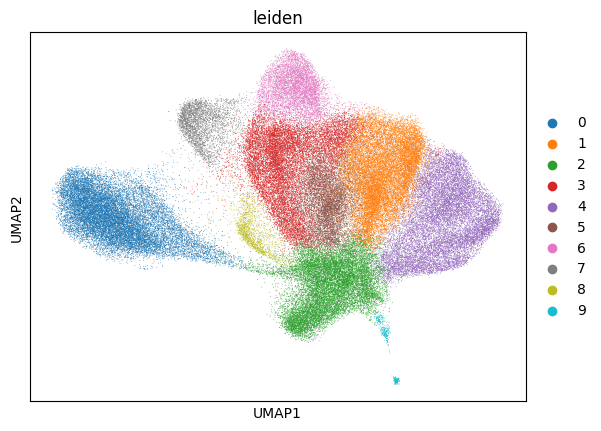

In [5]:
import scanpy as sc

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.leiden(adata, resolution=0.5)
sc.tl.umap(adata)
sc.pl.umap(adata, color="leiden")

## Step 6: Spatial Graph and Visualization

Spatial omics datasets, unlike single-cell datasets, have spatial coordinates attached to cell-level information. We can use various functions such as `sq.pl.spatial_scatter` or `sq.pl.spatial_segment` to plot the images and spatial projections.

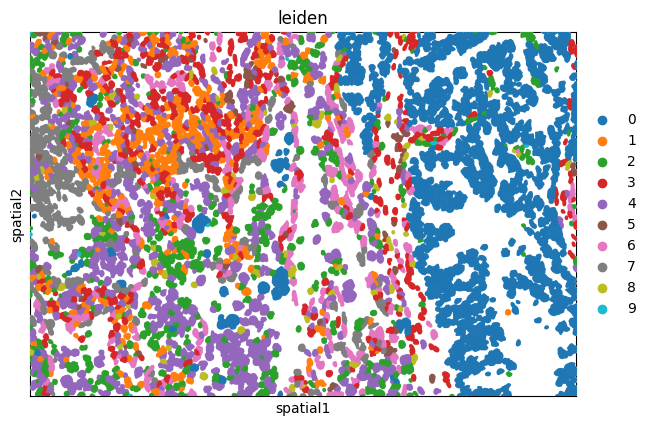

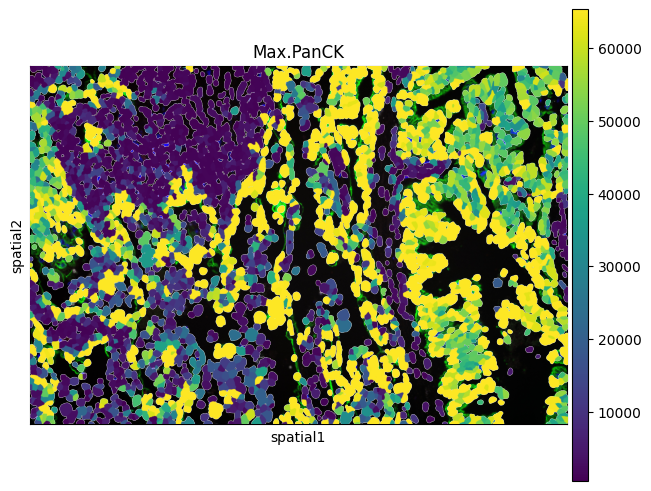

In [6]:
# Build spatial neighbors graph
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)
# Plot clusters in spatial coordinates
lib = "5" # FOV number
adata.uns["spatial"][lib]["images"]["segmentation"] = adata.uns["spatial"][lib]["images"]["segmentation"].copy() # Fix read-only segmentation mask if needed (for our file, yes)
sq.pl.spatial_segment(
    adata,
    color="leiden",
    seg_cell_id="cell_ID",
    library_id=lib, # FOV number
    library_key="fov",
    img=False, # morphology scan images
    size=1.5
)
# Plot metadata labels such as morphology stains
sq.pl.spatial_segment(
    adata,
    color="Max.PanCK",
    library_key="fov",
    library_id=lib, # FOV number
    seg_cell_id="cell_ID",
)

## Practice Questions (Answer in Markdown cells)
1. What do `.obs` and `.obsm["spatial"]` contain in AnnData?
2. How do spatial and expression clusters compare?
3. What biological patterns might the spatial clusters represent?
